In [1]:
import os
print("Current Working Directory:")
print(os.getcwd())

import os

os.chdir(r"C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis")

print(os.getcwd())
print(os.listdir("data"))


Current Working Directory:
c:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis\classification
C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis
['train.csv']


C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_24400\191773217.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


--- Final Model Comparison Table ---
              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.195000   0.208652 0.195000  0.187220
      Decision Tree  0.180000   0.182732 0.180000  0.180315
      Random Forest  0.193333   0.195387 0.193333  0.191406
                SVM  0.208333   0.213980 0.208333  0.204260
                KNN  0.186667   0.188469 0.186667  0.182695


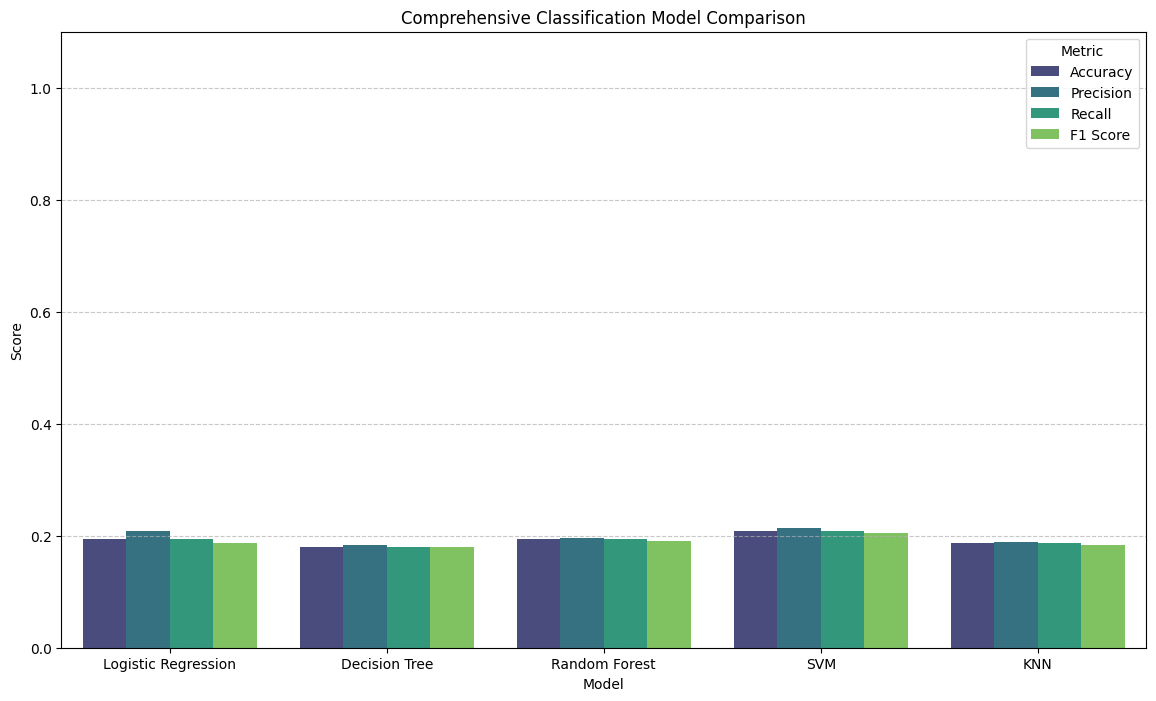

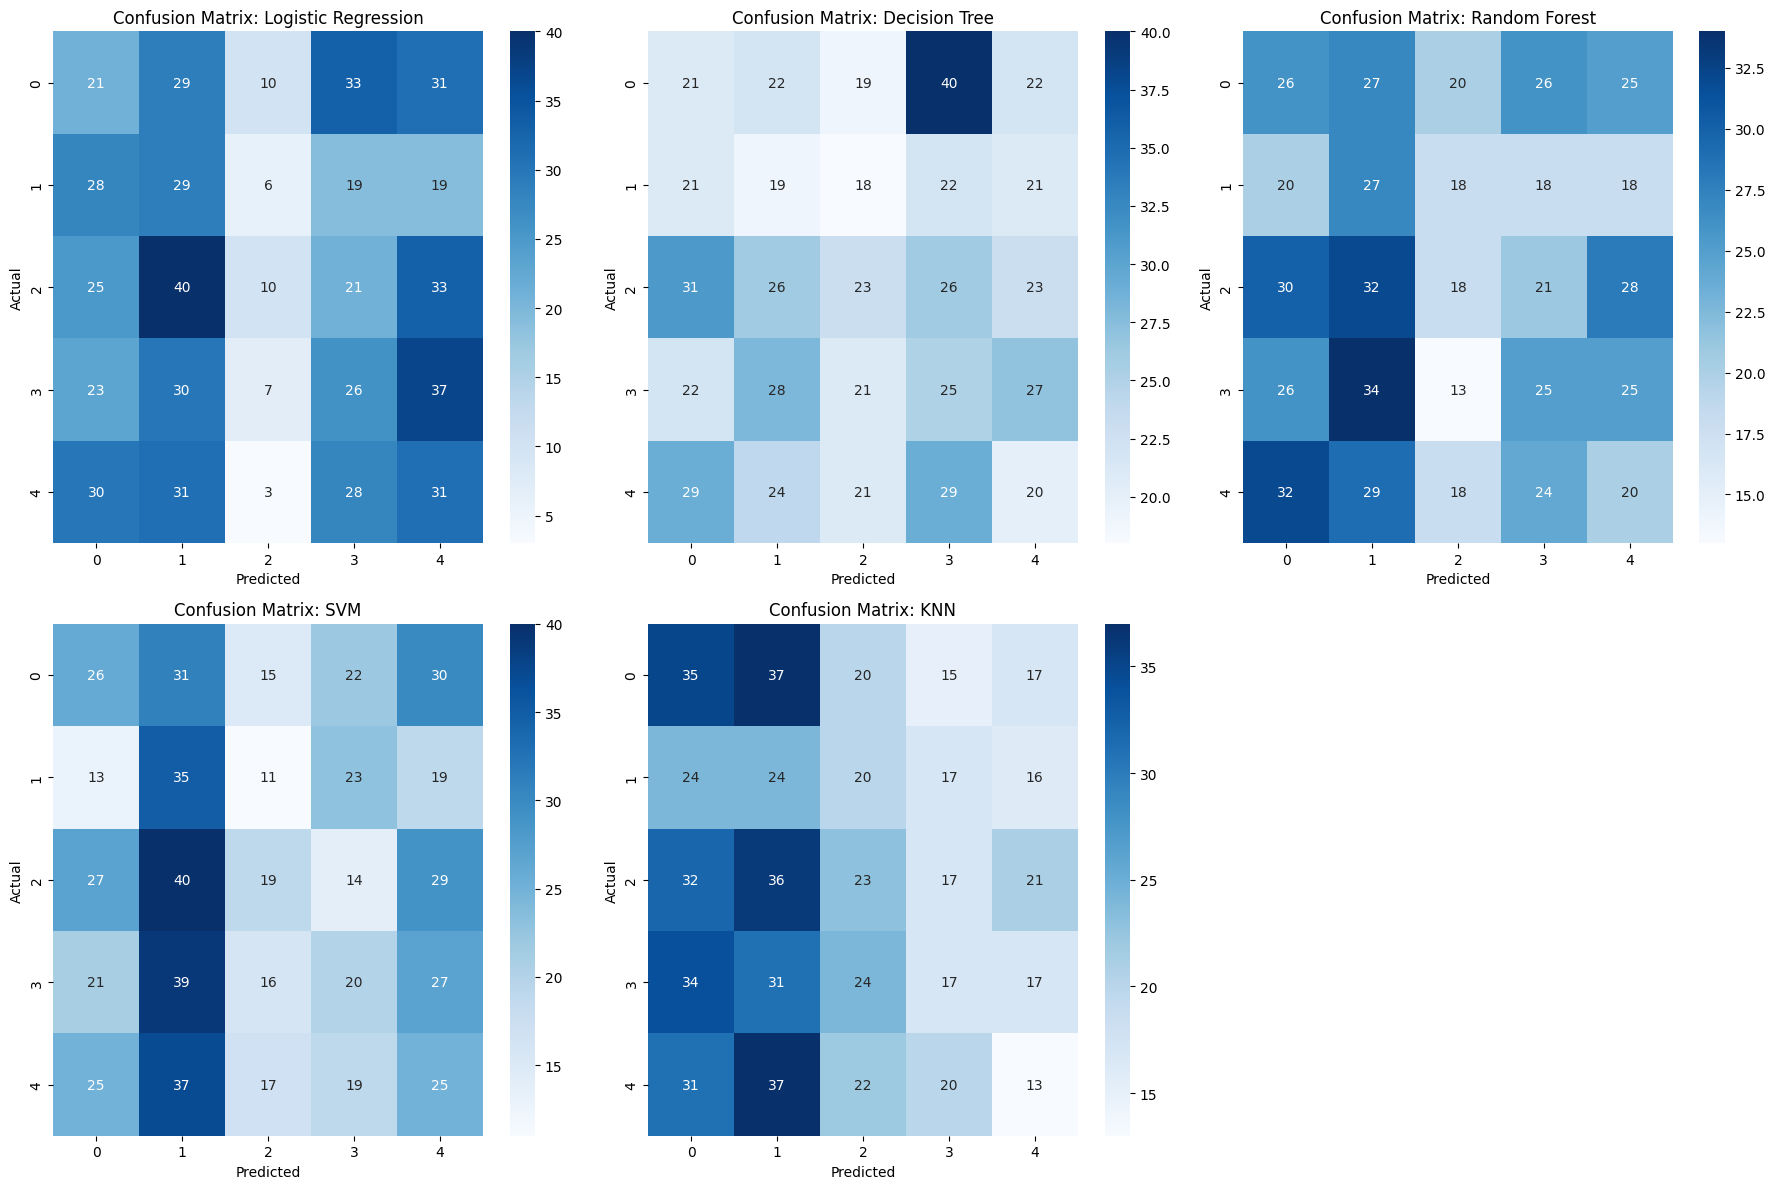

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Load the Dataset
df = pd.read_csv('data/train.csv') # Update path if needed
X = df.drop(columns=['Employee_Id', 'Stress_Level'])
y = df['Stress_Level']

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Preprocessing
# SVM, KNN, and Logistic Regression require scaling.
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# 4. Define the 5 Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=15)
}

# 5. Iterative Evaluation
results_list = []
cms = {}

for name, model in models.items():
    # Build Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    })
    
    cms[name] = confusion_matrix(y_test, y_pred)

# 6. Create Comparison Table
comparison_df = pd.DataFrame(results_list)
print("--- Final Model Comparison Table ---")
print(comparison_df.to_string(index=False))

# 7. Visualization: Metrics Comparison Bar Chart
plt.figure(figsize=(14, 8))
comparison_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Value')
sns.barplot(data=comparison_melted, x='Model', y='Value', hue='Metric', palette='viridis')
plt.title('Comprehensive Classification Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 8. Visualization: Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, matrix) in enumerate(cms.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide the last empty subplot (as we have 5 models and a 2x3 grid)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [5]:

# 5. Best Model Pipeline
# Using the RBF kernel as it handled the non-linear stress patterns best
best_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
])

# 6. Training
best_model_pipeline.fit(X_train, y_train)

# 7. Final Evaluation
y_pred = best_model_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"--- Best Model: Support Vector Machine ---")
print(f"Final Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- Best Model: Support Vector Machine ---
Final Accuracy: 0.1783

Classification Report:
               precision    recall  f1-score   support

           1       0.19      0.20      0.19       124
           2       0.13      0.19      0.16       101
           3       0.25      0.20      0.22       129
           4       0.19      0.18      0.18       123
           5       0.15      0.12      0.13       123

    accuracy                           0.18       600
   macro avg       0.18      0.18      0.18       600
weighted avg       0.18      0.18      0.18       600



In [6]:
# Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=15)
}

results = []
best_acc = 0
best_model_name = ""
best_cm = None
best_metrics = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    
    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        best_cm = confusion_matrix(y_test, y_pred)
        best_metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

results_df = pd.DataFrame(results)

# Plot 1: Accuracy Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Accuracy Comparison: Selecting the Best Model', fontsize=14)
plt.ylabel('Accuracy Score')
plt.ylim(0, 0.3) # Adjusted for low scores in this dataset
for i, v in enumerate(results_df['Accuracy']):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')
plt.savefig('model_accuracy_comparison.png')
plt.close()

# Plot 2: Best Model Metrics
best_metrics_df = pd.DataFrame(list(best_metrics.items()), columns=['Metric', 'Score'])
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', data=best_metrics_df, palette='plasma')
plt.title(f'Performance Metrics for Best Model: {best_model_name}', fontsize=14)
plt.ylim(0, 0.3)
for i, v in enumerate(best_metrics_df['Score']):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')
plt.savefig('best_model_metrics.png')
plt.close()

# Plot 3: Confusion Matrix for Best Model
plt.figure(figsize=(8, 6))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title(f'Confusion Matrix: {best_model_name} (The Best Model)', fontsize=14)
plt.xlabel('Predicted Stress Level')
plt.ylabel('Actual Stress Level')
plt.savefig('best_model_confusion_matrix.png')
plt.close()

# Save results to CSV for user
results_df.to_csv('model_comparison_results.csv', index=False)

print(f"Best Model Found: {best_model_name}")
print(results_df)

C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_24400\1541046201.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
C:\Users\vinay kumar\AppData\Local\Temp\ipykernel_24400\1541046201.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=best_metrics_df, palette='plasma')


Best Model Found: SVM
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.195000   0.208652  0.195000  0.187220
1        Decision Tree  0.180000   0.182732  0.180000  0.180315
2        Random Forest  0.193333   0.195387  0.193333  0.191406
3                  SVM  0.208333   0.213980  0.208333  0.204260
4                  KNN  0.186667   0.188469  0.186667  0.182695


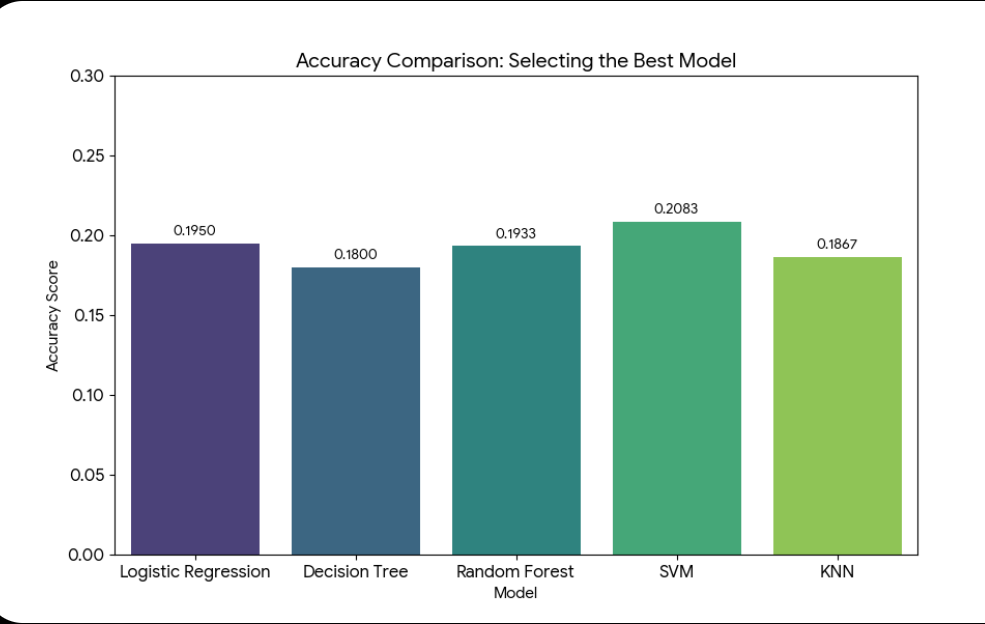